# Main Workflow for Offline Shack-Hartmann Analysis

This notebook is used after you finish the TODO parts in each program.

The file `iccp_tutorial_prog.pdf` is the tutorial document for this programming part. Please read it and follow the instructions.

After completing one program, you can come back to this notebook and run the corresponding command to test it.

The notebook does not rewrite the algorithms.  
It simply helps you run each script in the right order.

The full workflow is:

1. Load the optical configuration.
2. Run calibration to generate the calibration file.
3. Analyze different dataset groups.
4. Calculate the Zernike coefficients.

In short, this notebook is your testing and running guide for the offline Shack-Hartmann analysis.

## 1. Check the Current Python Environment

First, make sure this notebook is using the correct Python environment for this tutorial.

This environment only needs a few common packages:

- NumPy
- Pandas
- SciPy
- Matplotlib
- Pillow
- PyYAML

If the environment is not installed yet, you can install it using the `tutorial_environment.yml` file.

In [6]:
import sys
PYTHON = sys.executable
print(PYTHON)

c:\anaconda\envs\liteloc_env\python.exe


In [7]:
!{PYTHON} --version

Python 3.9.21


## 2. Check the Optical Configuration

The file `config.yaml` stores the objective optical parameters.

These include:

- camera pixel size
- microlens pitch
- microlens focal length
- wavelength
- Zernike aperture diameter

Later, the program will use these parameters to convert spot displacement in the image into wavefront slope.

In [8]:
from pathlib import Path

config_path = Path("config.yaml")
print(config_path.read_text(encoding="utf-8"))

# Objective optical information for the offline Shack-Hartmann tutorial.
# Length uses m, wavelength uses m, image coordinates use px.

paths:
  results_dir: results

camera:
  image_size_px: [1440, 1080]  # [width, height]
  pixel_pitch_m: 3.45e-6

optics:
  wavelength_m: 635.0e-9
  lenslet_pitch_m: 300.0e-6
  lenslet_focal_length_m: 14.6e-3
  sh_magnification: 1.0
  zernike_aperture_diameter_m: 4.4e-3



## 3. Run Calibration

In this step, we use four calibration images:

- reference
- defocus
- tilt x
- tilt y

These images are used to calculate the pupil center and the pupil x/y directions.

The expected output is:

`pupil_center_calibration.json`

The program will also generate three gated displacement plots.

All later Zernike calculations will use this calibration file.

In [9]:
!{PYTHON} calibration.py

Output: C:\Users\zhoucong\Desktop\ICCP Adaptive Optics Mini-Course 2026\sh_tutorial_prog\results\calibration_20260922_185733
Calibration JSON: C:\Users\zhoucong\Desktop\ICCP Adaptive Optics Mini-Course 2026\sh_tutorial_prog\results\calibration_20260922_185733\pupil_center_calibration.json
Latest calibration JSON: c:\Users\zhoucong\Desktop\ICCP Adaptive Optics Mini-Course 2026\sh_tutorial_prog\results\latest_pupil_center_calibration.json
Center: (637.69, 680.50) px
X axis: [0.9995263939403201, 0.03077316715354733]
Y axis: [-0.028154955971149725, -0.9996035706490162]


## 3.1 View the Defocus Gate Displacement Plot

After running calibration, the program will find the latest `results/calibration_*` folder and display:

`defocus_displacements_gate_center.png`

This image is used to check whether the calibration result looks reasonable.

In this plot, you can check:

- whether the estimated pupil center is close to the center of the spot array
- whether the defocus displacement vectors show a reasonable radial pattern
- whether the pupil x/y directions look correct

This is a quick visual check before using the calibration file for Zernike reconstruction.

results\calibration_20260922_185733\defocus_displacements_gate_center.png


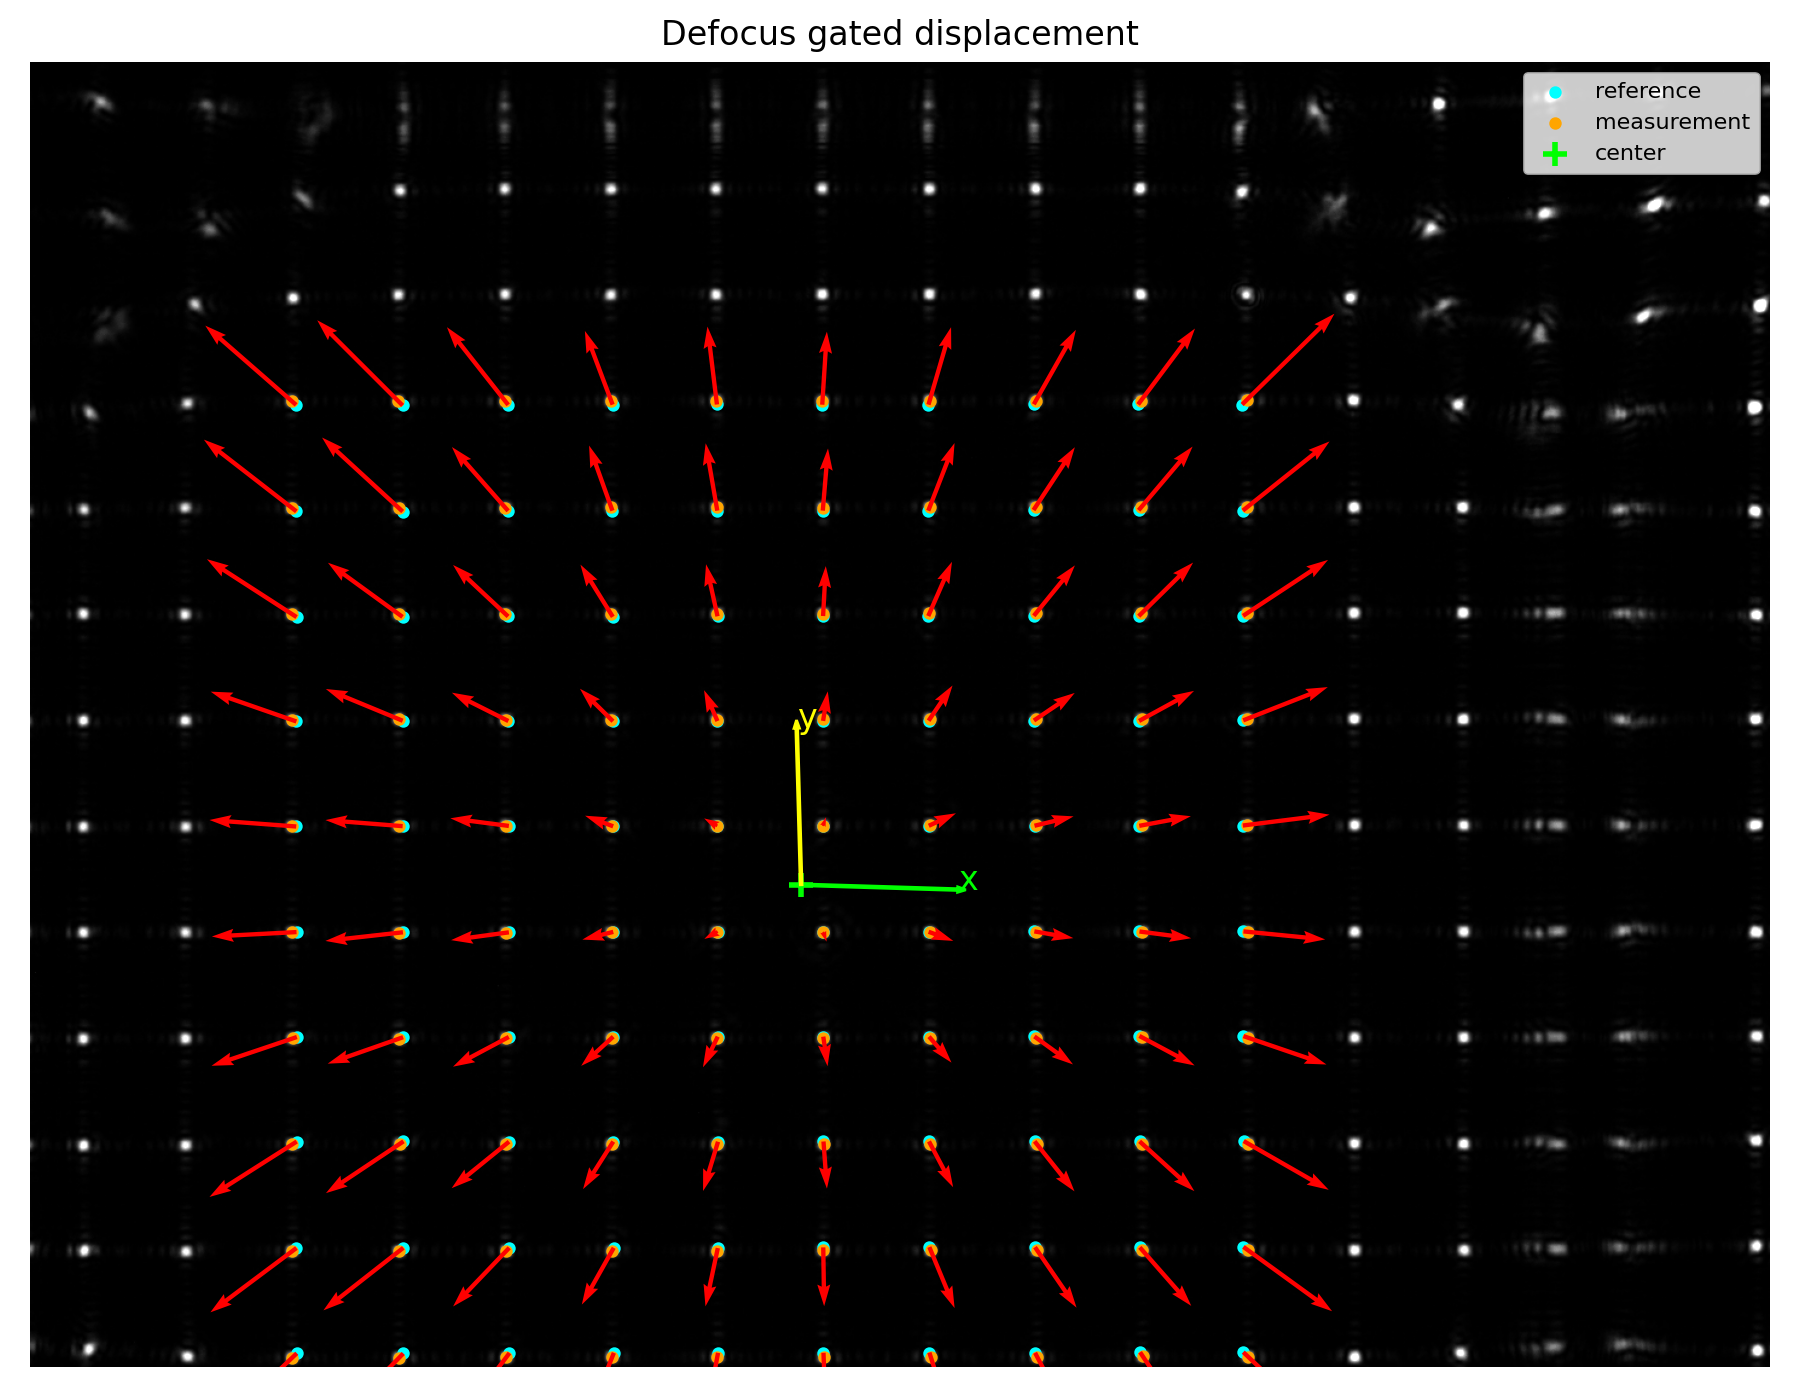

In [10]:
from pathlib import Path
from IPython.display import Image, display

calibration_dirs = sorted(Path("results").glob("calibration_*"), key=lambda p: p.stat().st_mtime)
latest_calibration_dir = calibration_dirs[-1]
defocus_plot = latest_calibration_dir / "defocus_displacements_gate_center.png"

print(defocus_plot)
display(Image(filename=str(defocus_plot)))

## 4. Set the Calibration File Path

The later Zernike analysis needs to read the calibration file generated by `calibration.py`.

By default, we will use the latest calibration file that was just created.

In [ ]:
CALIBRATION_FILE = "results/latest_pupil_center_calibration.json"

# If you want to use the calibration file from a previous experiment,
# you can change it to the following line:
# CALIBRATION_FILE = "results/defocus_center_20260707_224837_final/pupil_center_calibration.json"

print(CALIBRATION_FILE)

results/latest_pupil_center_calibration.json


## 4.1 Define Result Viewing Functions

The following three functions are used to view the latest output results from:

- `first_10_zernike`
- `last_10_zernike`
- `mixed_zernike`

These functions are only used for checking the results more easily.

In [7]:
from pathlib import Path
from IPython.display import Image, display

def _show_latest_group_result(group_name):
    result_dirs = sorted(Path("results").glob(f"zernike_{group_name}_*"), key=lambda p: p.stat().st_mtime)
    if not result_dirs:
        raise FileNotFoundError(f"No result folder found for group: {group_name}")

    latest_dir = result_dirs[-1]
    sample_dirs = sorted(path for path in latest_dir.iterdir() if path.is_dir())
    if not sample_dirs:
        raise FileNotFoundError(f"No sample folders found in: {latest_dir}")

    sample_dir = sample_dirs[0]
    displacement_png = sample_dir / "spot_displacements_gate.png"
    comparison_png = sample_dir / "true_vs_measured_zernike.png"

    print(f"Result folder: {latest_dir}")
    print(f"Sample shown: {sample_dir.name}")
    print(displacement_png)
    display(Image(filename=str(displacement_png)))
    print(comparison_png)
    display(Image(filename=str(comparison_png)))

def show_latest_first_10_result():
    _show_latest_group_result("first_10_zernike")

def show_latest_last_10_result():
    _show_latest_group_result("last_10_zernike")

def show_latest_mixed_result():
    _show_latest_group_result("mixed_zernike")

## 5. Analyze the First Ten Individual Zernike Samples

This dataset group is used to check whether the low-order Zernike modes are calculated correctly.

Each sample usually contains only one non-zero Zernike coefficient.

In [8]:
!{PYTHON} analyze_zernike.py --group first_10_zernike --calibration-file {CALIBRATION_FILE}

sample_01_j02_tilt_x: matched 113 spots, fit 112 spots
sample_02_j03_tilt_y: matched 113 spots, fit 112 spots
sample_03_j04_defocus: matched 113 spots, fit 112 spots
sample_04_j05_astig_45: matched 113 spots, fit 112 spots
sample_05_j06_astig_0: matched 113 spots, fit 112 spots
sample_06_j07_coma_y: matched 113 spots, fit 112 spots
sample_07_j08_coma_x: matched 113 spots, fit 112 spots
sample_08_j09_trefoil_y: matched 113 spots, fit 112 spots
sample_09_j10_trefoil_x: matched 113 spots, fit 112 spots
sample_10_j11_spherical: matched 111 spots, fit 110 spots
Output: C:\Users\zhoucong\Desktop\sh_tutorial_prog\results\zernike_first_10_zernike_20260709_113749


### View the First Sample in the First Ten Zernike Group

Display the first sample from the latest `first_10_zernike` analysis result.

This will show:

- `spot_displacements_gate.png`
- `true_vs_measured_zernike.png`

Result folder: results\zernike_first_10_zernike_20260709_113749
Sample shown: sample_01_j02_tilt_x
results\zernike_first_10_zernike_20260709_113749\sample_01_j02_tilt_x\spot_displacements_gate.png


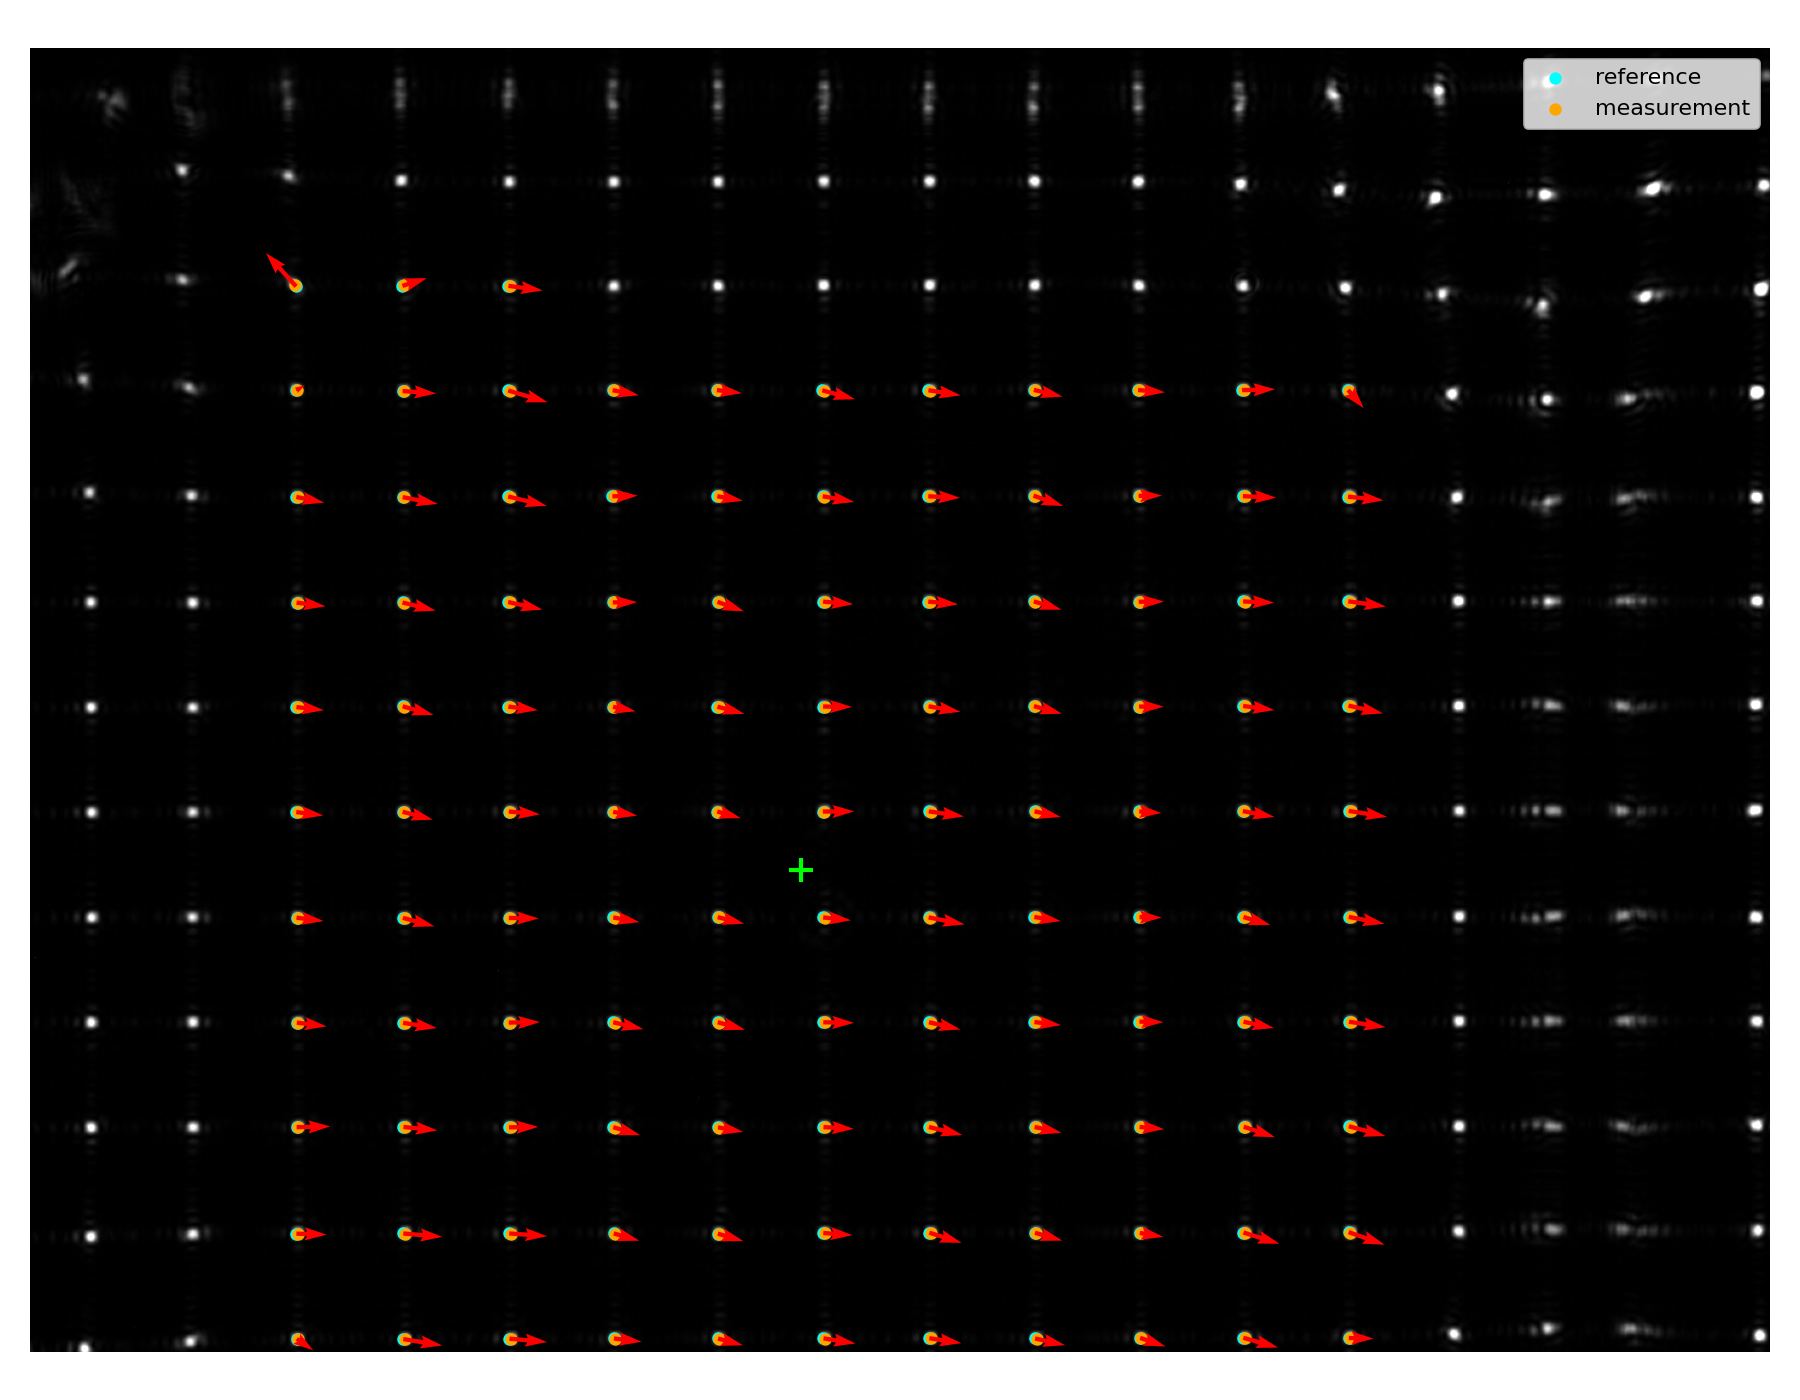

results\zernike_first_10_zernike_20260709_113749\sample_01_j02_tilt_x\true_vs_measured_zernike.png


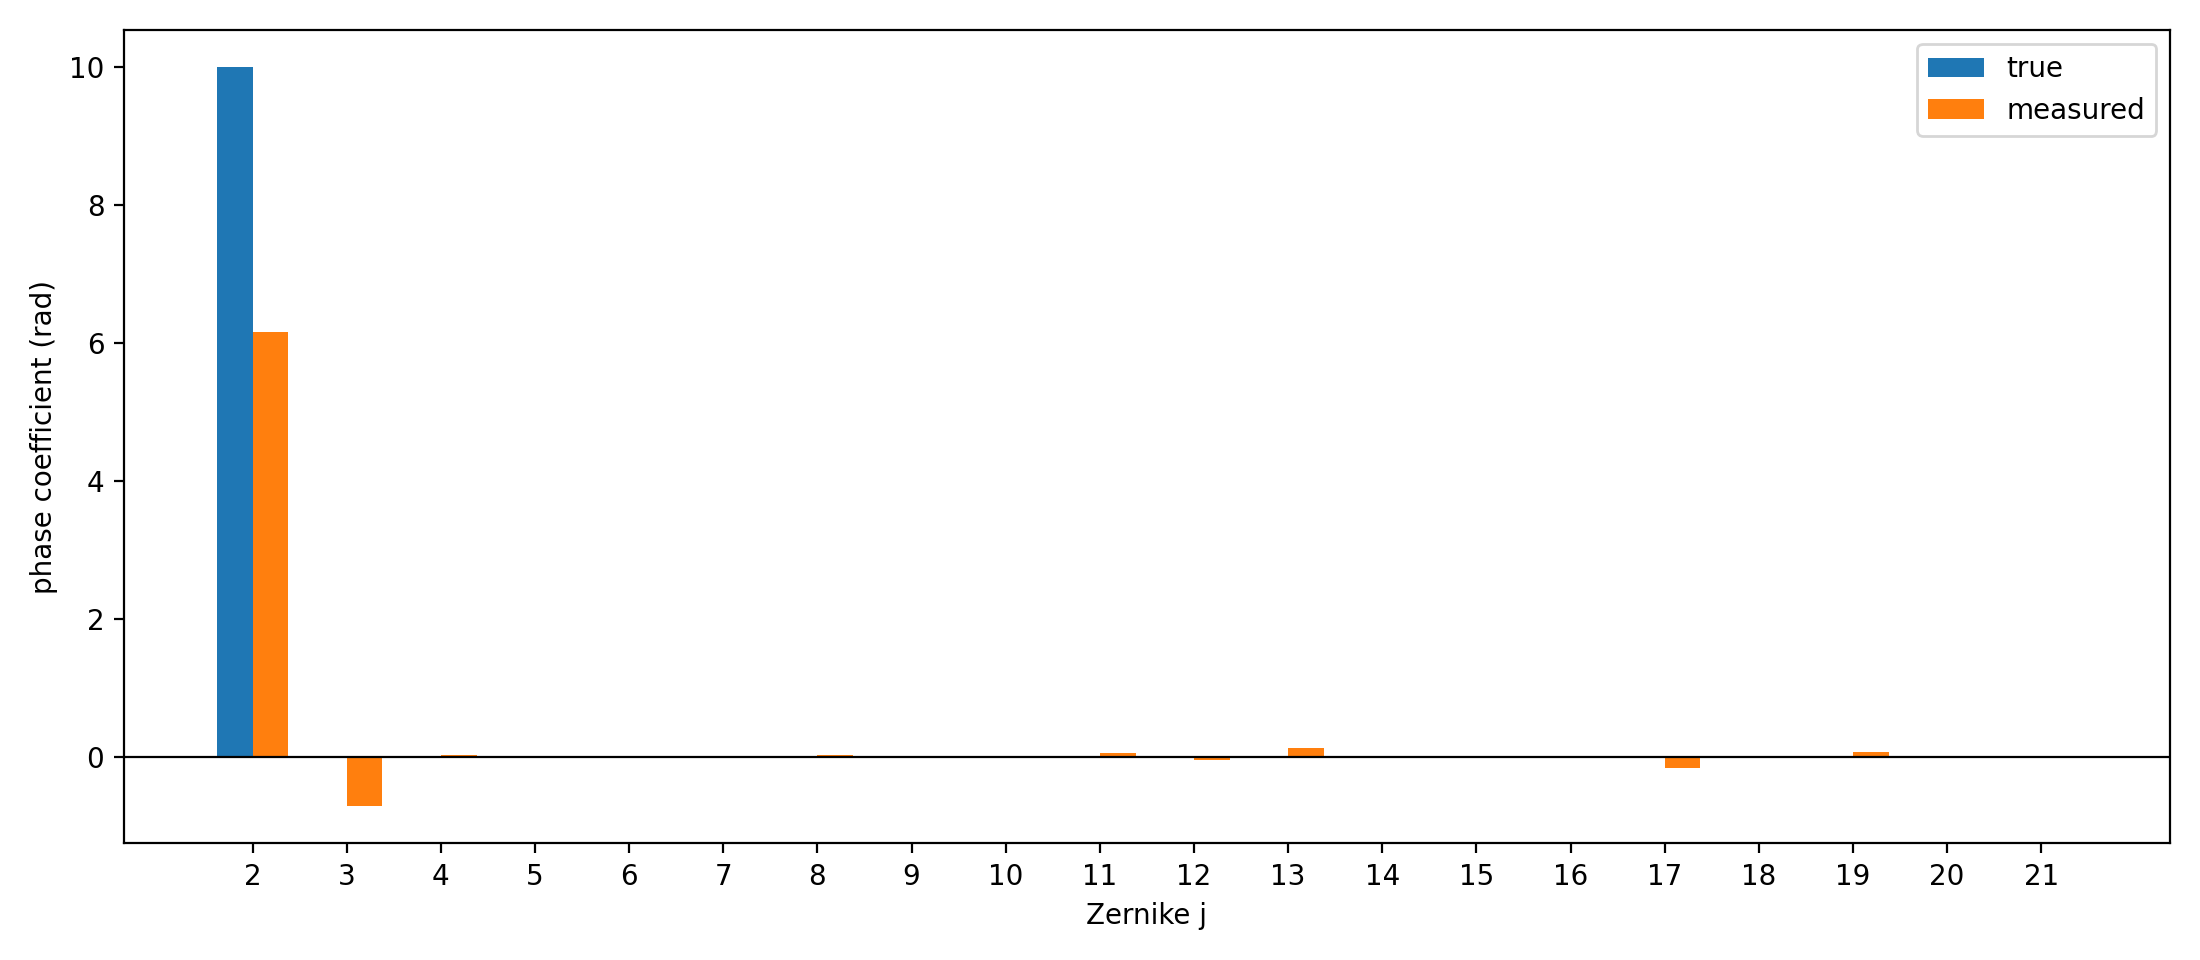

In [9]:
show_latest_first_10_result()

## 6. Analyze the Last Ten Individual Zernike Samples

This dataset group is used to check higher-order Zernike modes.

Higher-order modes are usually more sensitive to the pupil gate, spot matching
and the effective aperture size

In [10]:
!{PYTHON} analyze_zernike.py --group last_10_zernike --calibration-file {CALIBRATION_FILE}

sample_01_j12_secondary_astig_45: matched 112 spots, fit 111 spots
sample_02_j13_secondary_astig_0: matched 113 spots, fit 112 spots
sample_03_j15_quadrafoil_0: matched 113 spots, fit 112 spots
sample_04_j17_secondary_coma_x: matched 112 spots, fit 111 spots
sample_05_j19_secondary_trefoil_x: matched 112 spots, fit 111 spots
sample_06_j21_pentafoil_x: matched 113 spots, fit 112 spots
Output: C:\Users\zhoucong\Desktop\sh_tutorial_prog\results\zernike_last_10_zernike_20260709_113806


### View the First Sample in the Last Ten Zernike Group

Display the first sample from the latest `last_10_zernike` analysis result.

This will show:

- `spot_displacements_gate.png`
- `true_vs_measured_zernike.png`

Result folder: results\zernike_last_10_zernike_20260709_113806
Sample shown: sample_01_j12_secondary_astig_45
results\zernike_last_10_zernike_20260709_113806\sample_01_j12_secondary_astig_45\spot_displacements_gate.png


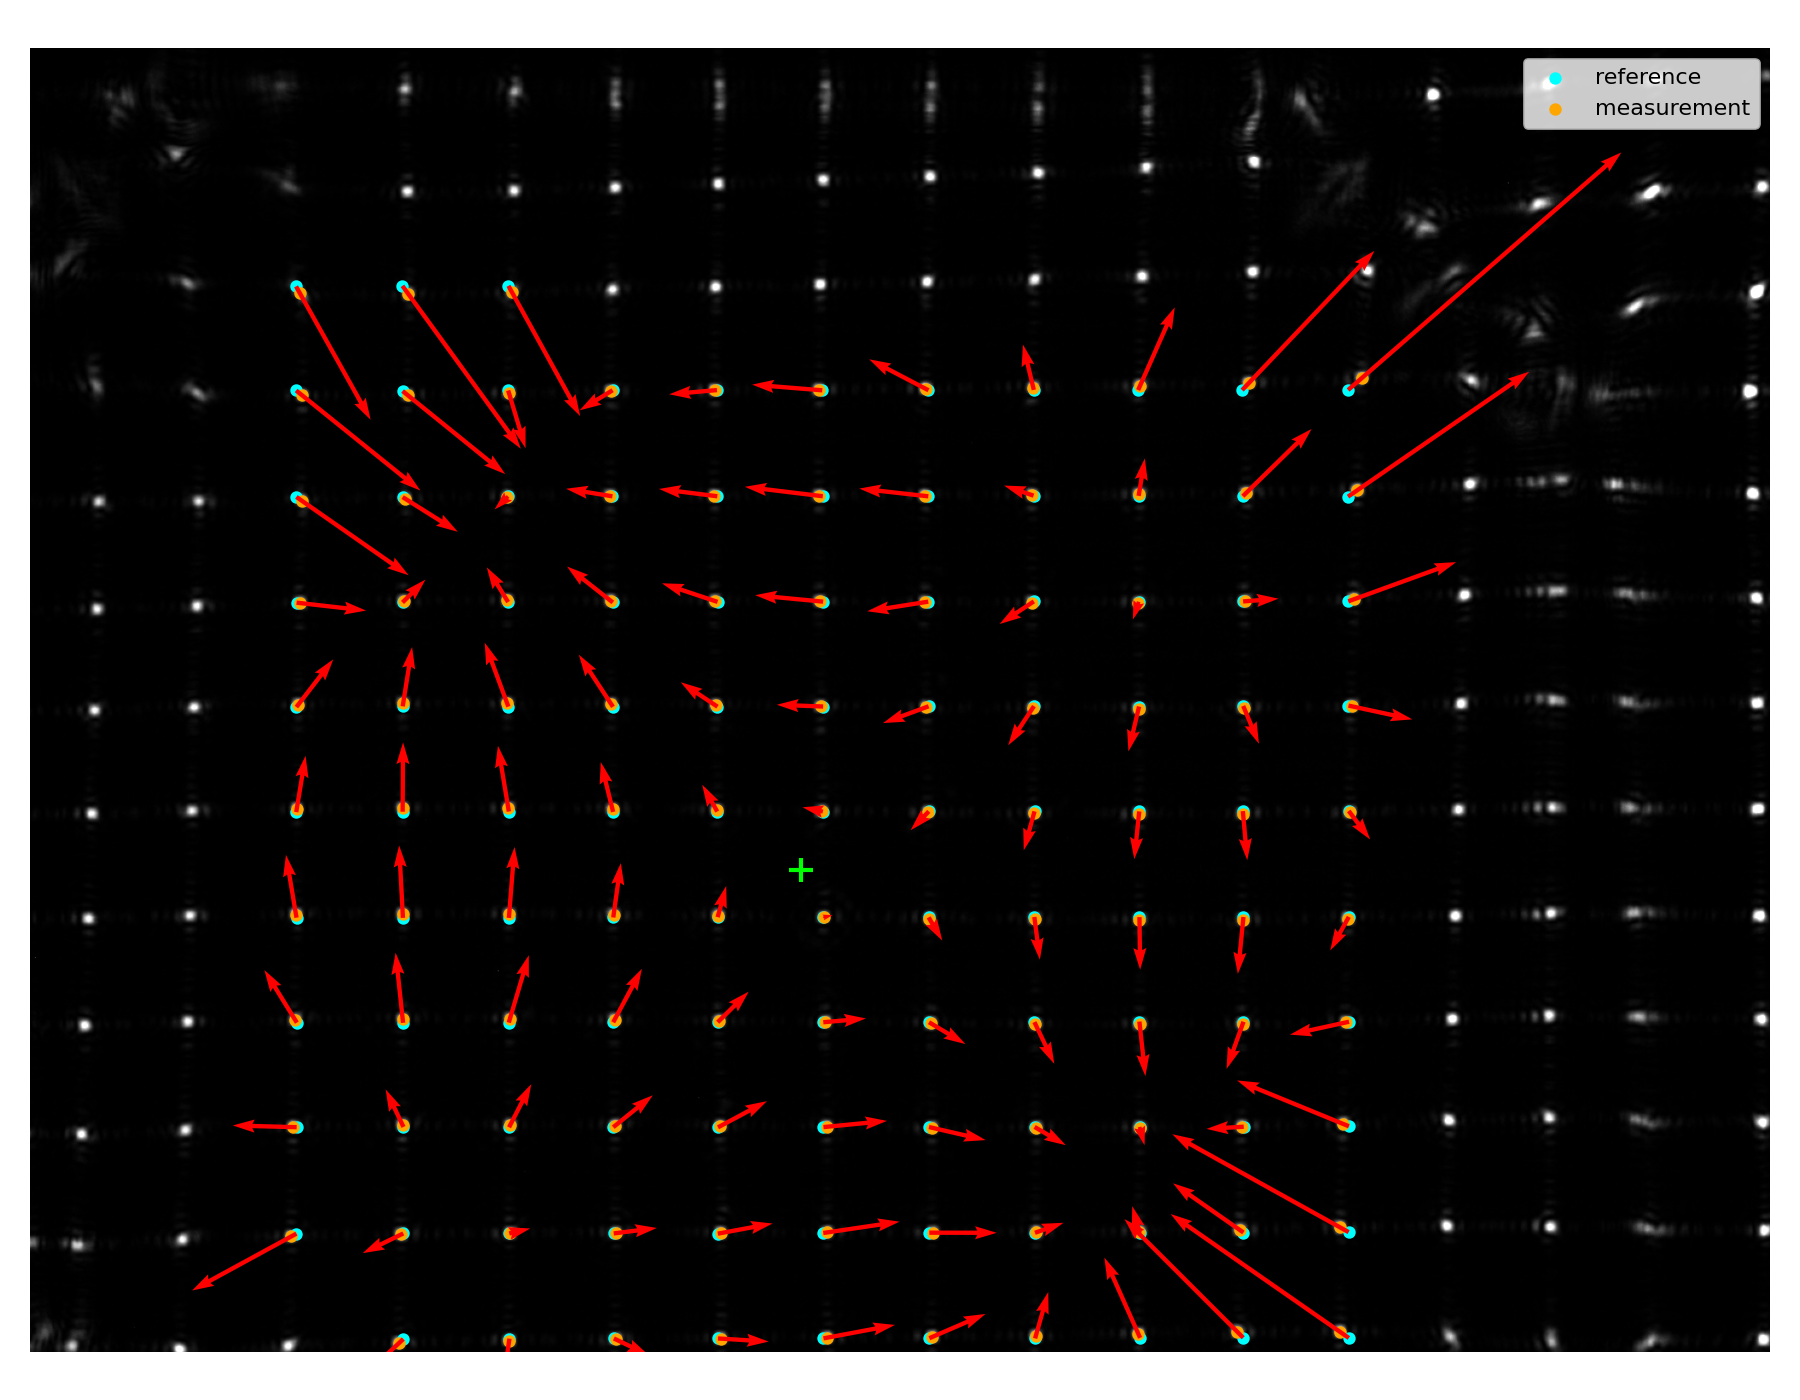

results\zernike_last_10_zernike_20260709_113806\sample_01_j12_secondary_astig_45\true_vs_measured_zernike.png


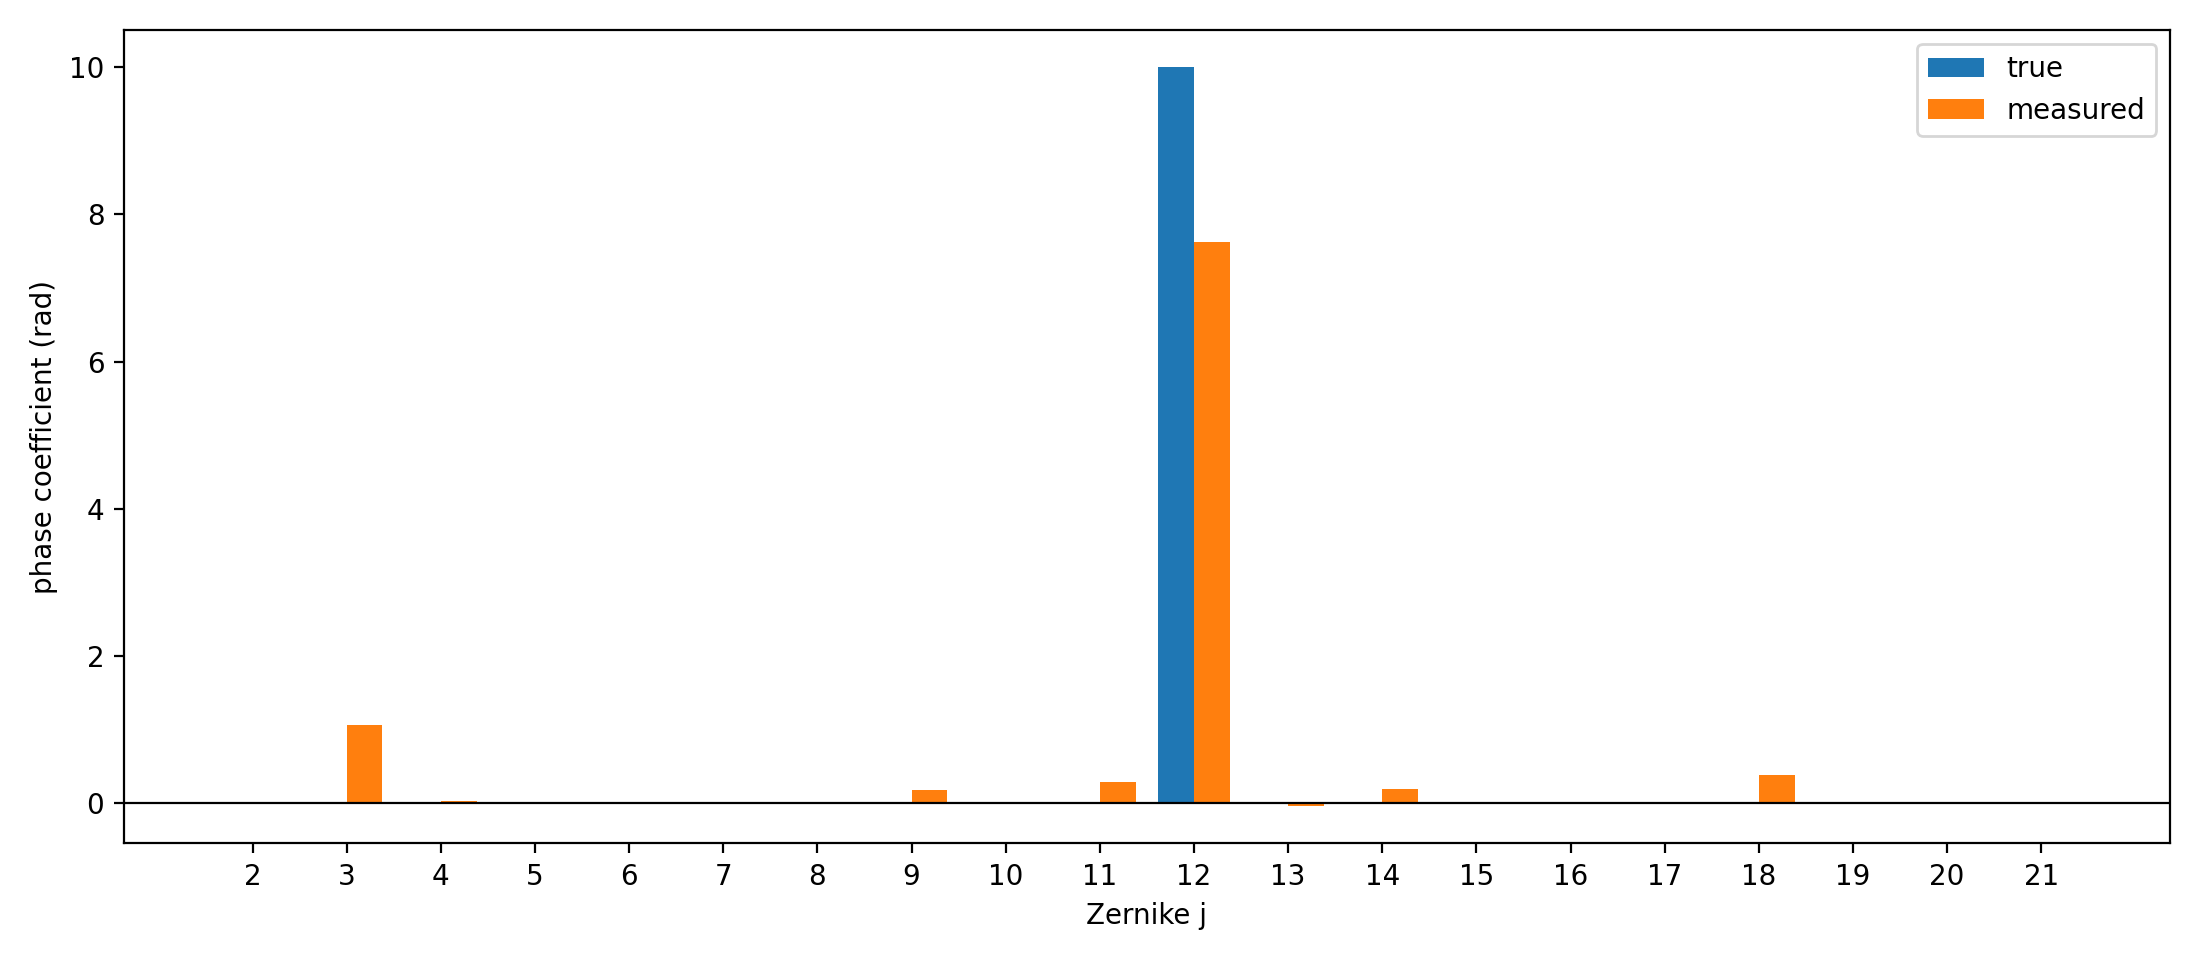

In [11]:
show_latest_last_10_result()

## 7. Analyze the Mixed Zernike Samples

The mixed samples contain several non-zero Zernike coefficients at the same time.

This is closer to a real measurement case.

It is also useful for observing crosstalk between different Zernike modes.

In [8]:
!{PYTHON} analyze_zernike.py --group mixed_zernike --calibration-file {CALIBRATION_FILE}

sample_01_j03+j07+j10: matched 113 spots, fit 112 spots
sample_02_j03+j07+j10+j15: matched 113 spots, fit 112 spots
sample_03_j03+j07+j10+j15+j19: matched 113 spots, fit 112 spots
sample_04_j03+j07+j08+j10+j15+j19: matched 113 spots, fit 112 spots
sample_05_j03+j05+j07+j08+j10+j15+j19: matched 113 spots, fit 112 spots
sample_06_j03+j05+j07+j08+j10+j12+j15+j19: matched 113 spots, fit 112 spots
sample_07_j03+j05+j07+j08+j10+j12+j15+j17+j19: matched 113 spots, fit 112 spots
sample_08_j03+j05+j07+j08+j10+j12+j15+j17+j19+j21: matched 113 spots, fit 112 spots
sample_09_j03+j05+j07+j08+j10+j12+j13+j15+j17+j19+j21: matched 113 spots, fit 112 spots
Output: C:\Users\zhoucong\Desktop\sh_tutorial_prog\results\zernike_mixed_zernike_20260709_110737


### View the First Sample in the Mixed Zernike Group

Display the first sample from the latest `mixed_zernike` analysis result.

This will show:

- `spot_displacements_gate.png`
- `true_vs_measured_zernike.png`

Result folder: results\zernike_mixed_zernike_20260709_110737
Sample shown: sample_01_j03+j07+j10
results\zernike_mixed_zernike_20260709_110737\sample_01_j03+j07+j10\spot_displacements_gate.png


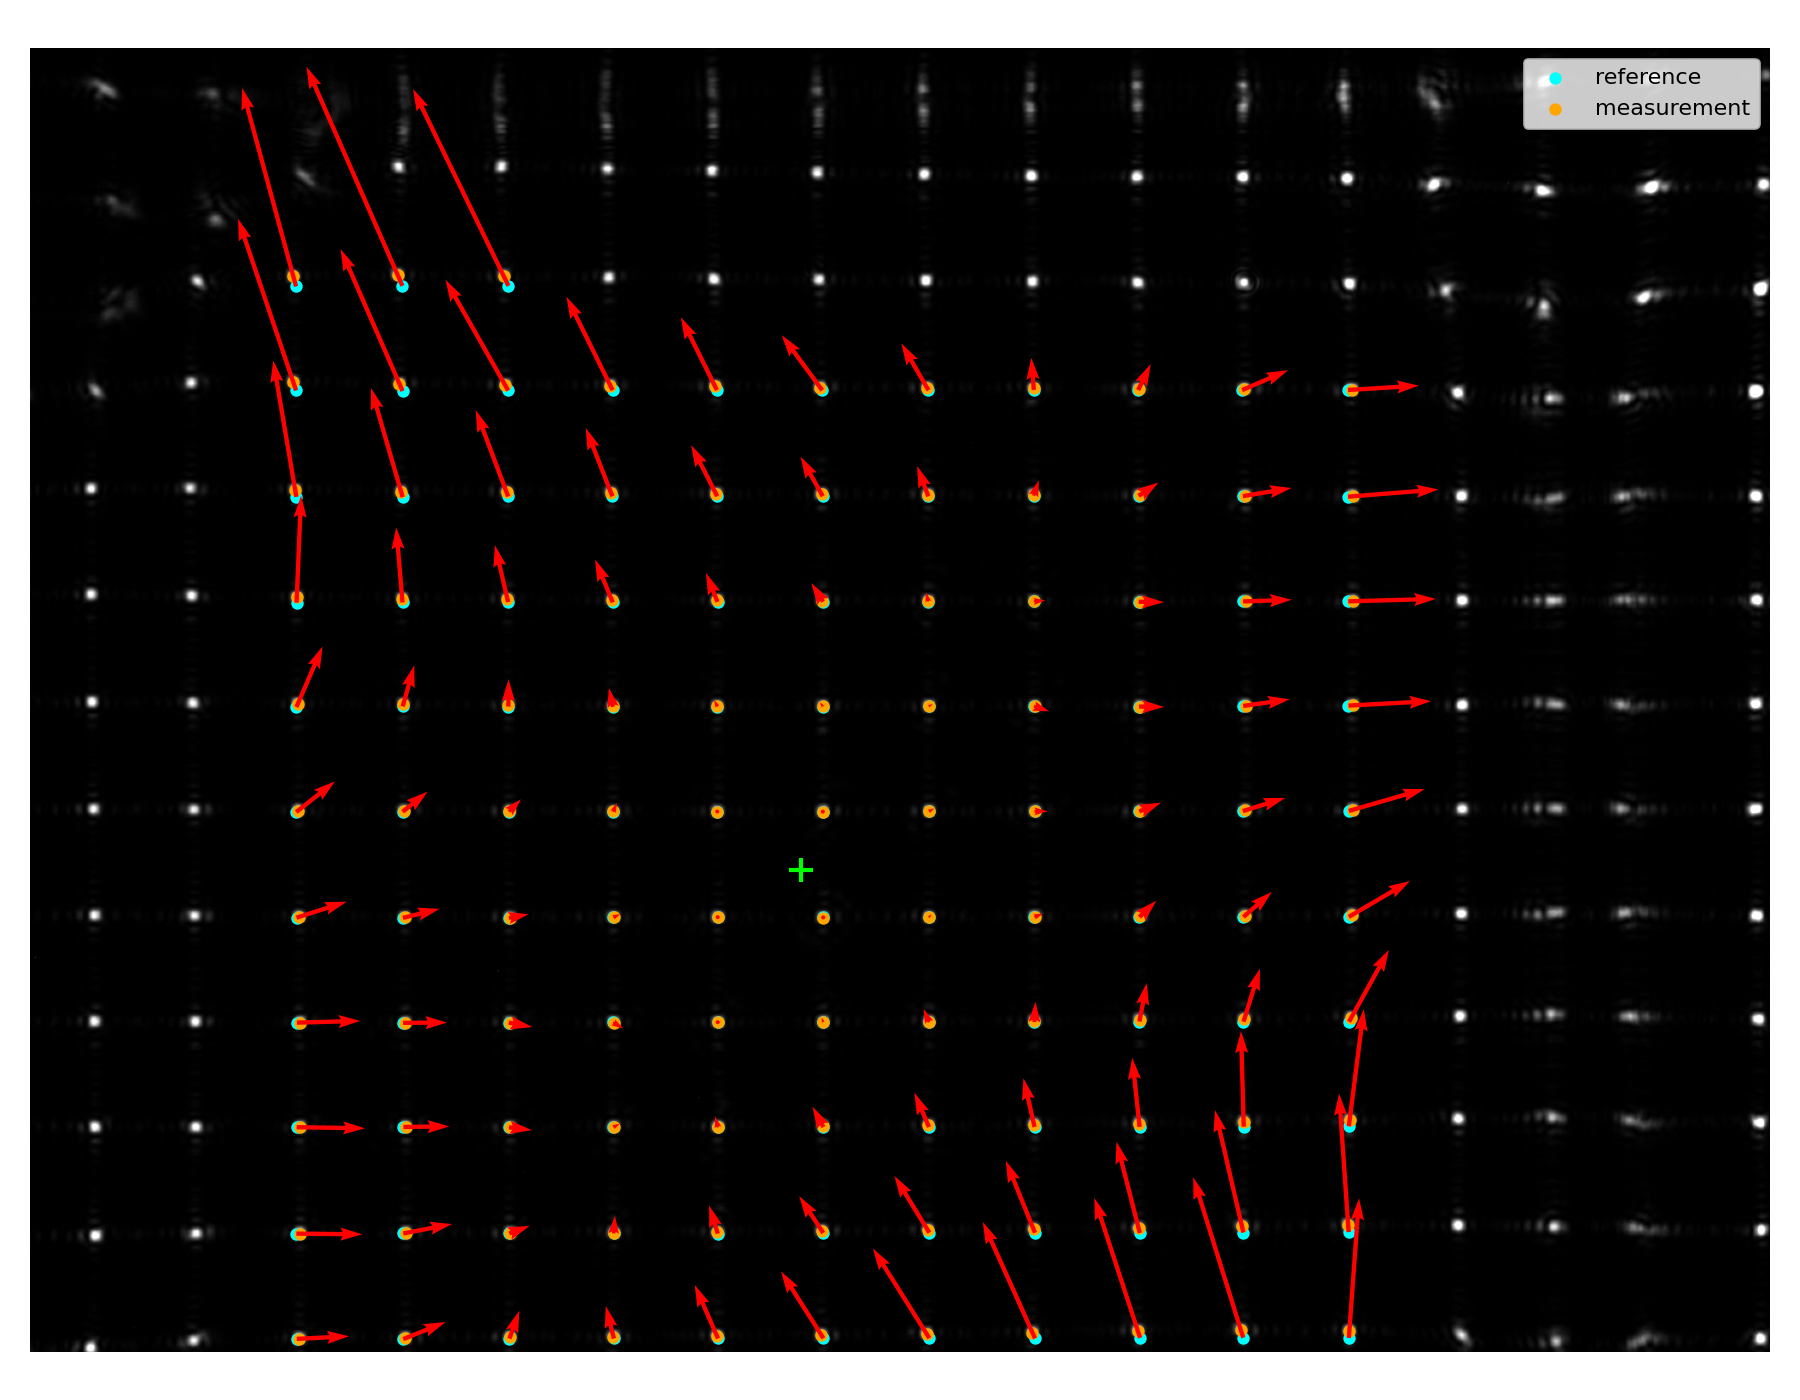

results\zernike_mixed_zernike_20260709_110737\sample_01_j03+j07+j10\true_vs_measured_zernike.png


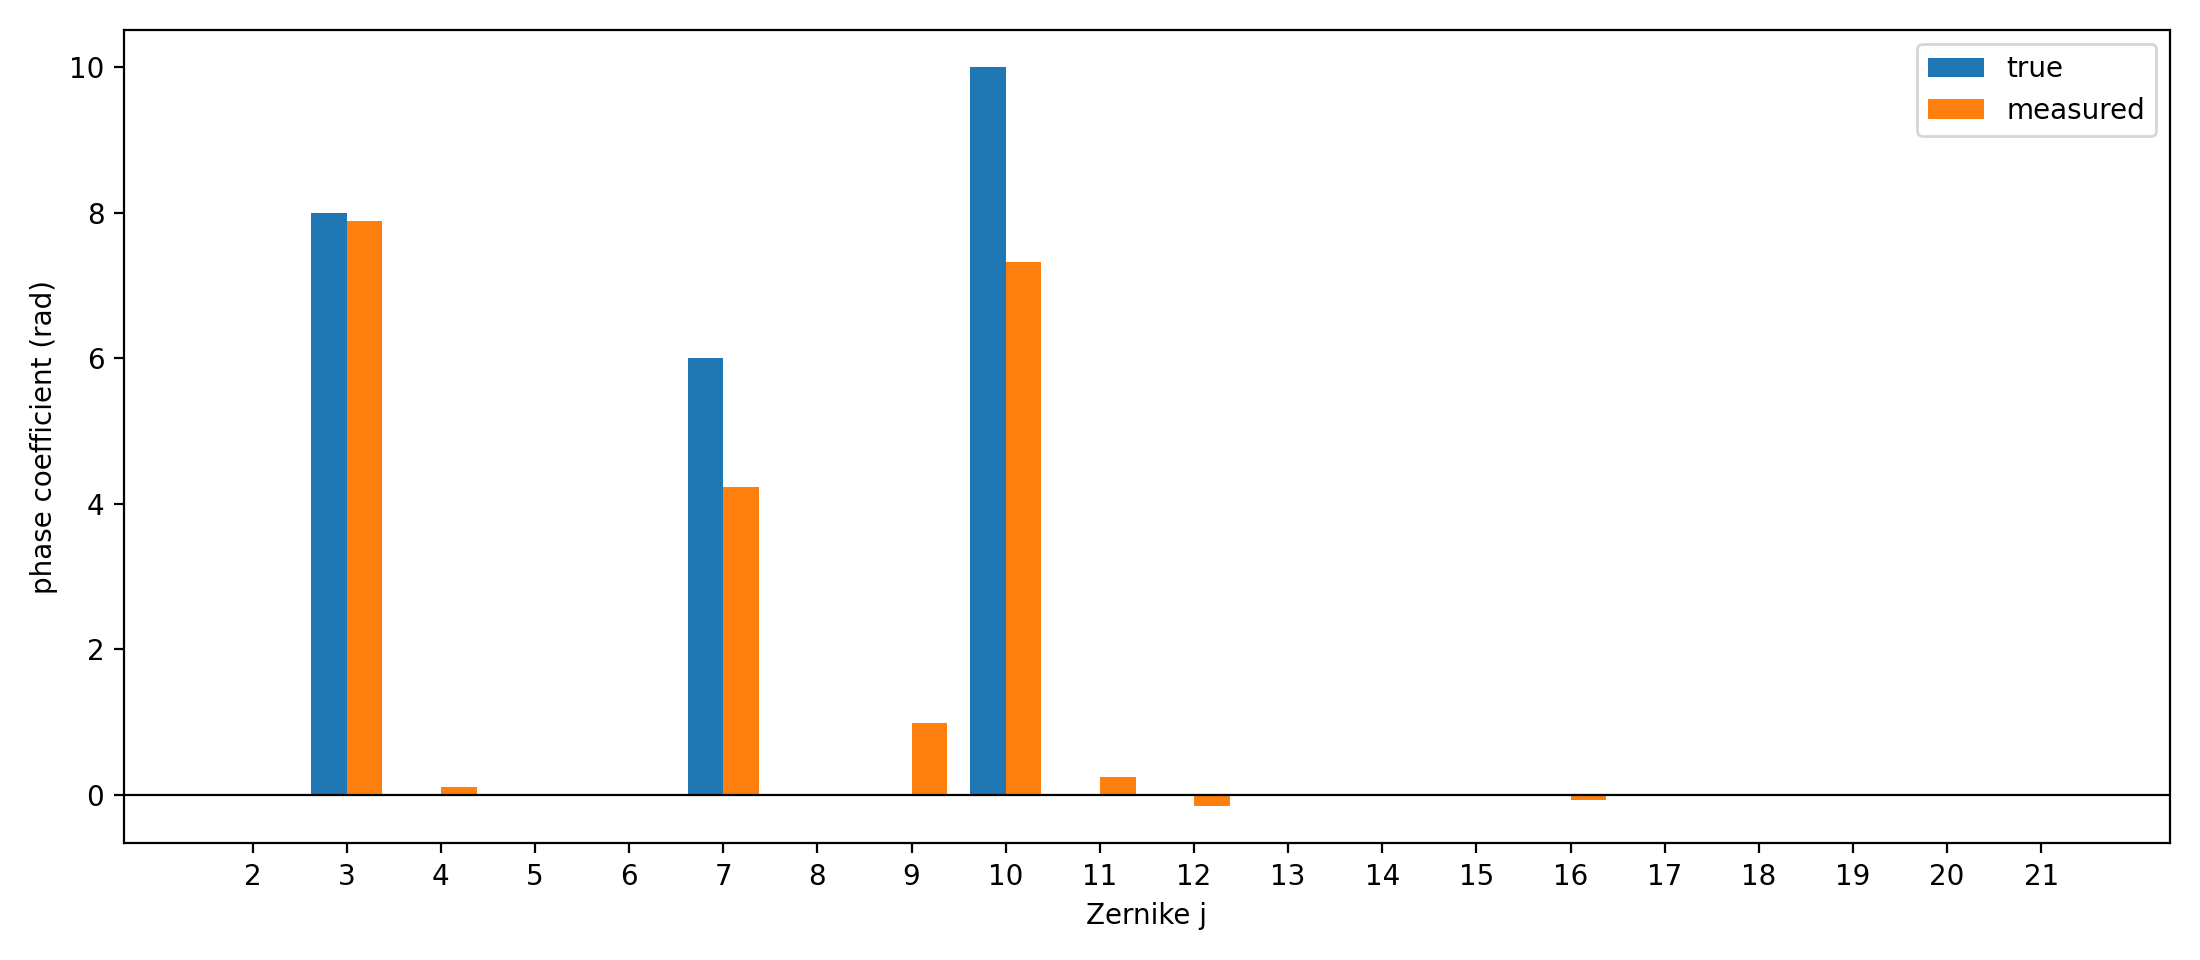

In [12]:
show_latest_mixed_result()

## 8. View the Output Files

Each analysis creates a new folder with a timestamp under `results/`.

The main output files are:

- `measured_zernike_coeffs.csv`  
  The measured Zernike coefficients.

- `true_vs_measured_zernike_coeffs.csv`  
  A table comparing the true and measured coefficients.

- `true_vs_measured_zernike.png`  
  A bar plot comparing the true and measured coefficients.

- `spot_displacements_gate.png`  
  The gated spot displacement plot used for Zernike fitting.

## 9. Check the Results

Compare the true and measured Zernike coefficients.

Your result is considered successful if:

- the largest coefficient appears at the correct Zernike mode
- the measured value is close to the true value
- the other coefficients remain small

If these conditions are satisfied, your Shack-Hartmann analysis is working correctly!